In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast
import utils as ut
import importlib

In [3]:
# import data and do some cleaning
df = pd.read_csv('smol-ai-news_may1.csv')
df['date'] = pd.to_datetime(df['date'])
df['month'] = pd.to_datetime(df['month'])
df['day'] = pd.to_datetime(df['day'])
df['my_year'] = df.date.dt.to_period('Y').dt.to_timestamp()

# convert objects back to lists
for col in ['models', 'topics', 'people']:
    df[col] = df[col].apply(ast.literal_eval)


df.head(2)

,year,date,title,description,models,topics,people,month,day,my_year
0,2025,2025-04-30,chatgpt responds to glazegate + lmarena respon...,**openai** faced backlash after a controversia...,"[qwen3-235b-a22b, qwen3, qwen3-moe, llama-4]","[model-releases, model-benchmarking, performan...","[joannejang, arankomatsuzaki, karpathy, saraho...",2025-04-01,2025-04-30,2025-01-01
1,2025,2025-04-29,llamacon: meta ai gets into the llama api plat...,**meta** celebrated progress in the **llama** ...,"[llama-4, qwen3, qwen3-235b-a22b, qwen3-30b-a3...","[model-release, fine-tuning, reinforcement-lea...","[reach_vb, huybery, teortaxestex, awnihannun, ...",2025-04-01,2025-04-29,2025-01-01


In [4]:
# Get "expanded" dfs for selected cols
df_topics = df.explode('topics')
df_models = df.explode('models')
df_people = df.explode('people')

In [7]:
# get some idea about the granualarity
print('-' * 30)
print('Original dataset')
print('-' * 30)
print('Days per year in dataset')
print(df.day.groupby(df.year).nunique())
print('-' * 30)
print('Months per year in dataset')
print(df.month.groupby(df.year).nunique())
print('-' * 30)
days_per_month = df.day.groupby(df.year).nunique() / df.month.groupby(df.year).nunique()
print('Days per month in dataset')
print(days_per_month)
print('-' * 30)


------------------------------
Original dataset
------------------------------
Days per year in dataset
year
2023     20
2024    214
2025     76
Name: day, dtype: int64
------------------------------
Months per year in dataset
year
2023     1
2024    12
2025     4
Name: month, dtype: int64
------------------------------
Days per month in dataset
year
2023    20.000000
2024    17.833333
2025    19.000000
dtype: float64
------------------------------


# Topics - slopegraph

Let's thing about granularity first.

- Original dataset: day
- Expanded dataset: day x topic (or category)

Three alternative metrics

1. Count of days with news for topic $t$ and year $y$: $CT_{y,t}$
2. Normalized per month:  $ CT_{y,t}/M(y) $
2. Normalized per day:  $ CT_{y,t}/D(y) $

Note that:
$$
\frac{CT_{y,t}}{D(y)} = \frac{CT_{y,t}}{M(y)} \times \frac{M(y)}{D(y)} \Longleftrightarrow \frac{CT_{y,t}}{D(y)} \times \frac{D(y)}{M(y)} = \frac{CT_{y,t}}{M(y)} 
$$

So I can make the two comparable if I adjust the the count by D(y)/M(y) (I'm multiplying by 30.4, but it could be done with the numbers above)

### Original topics

I can do several things:
1. Rank vs. actual counts
2. Counts: normalized or not 

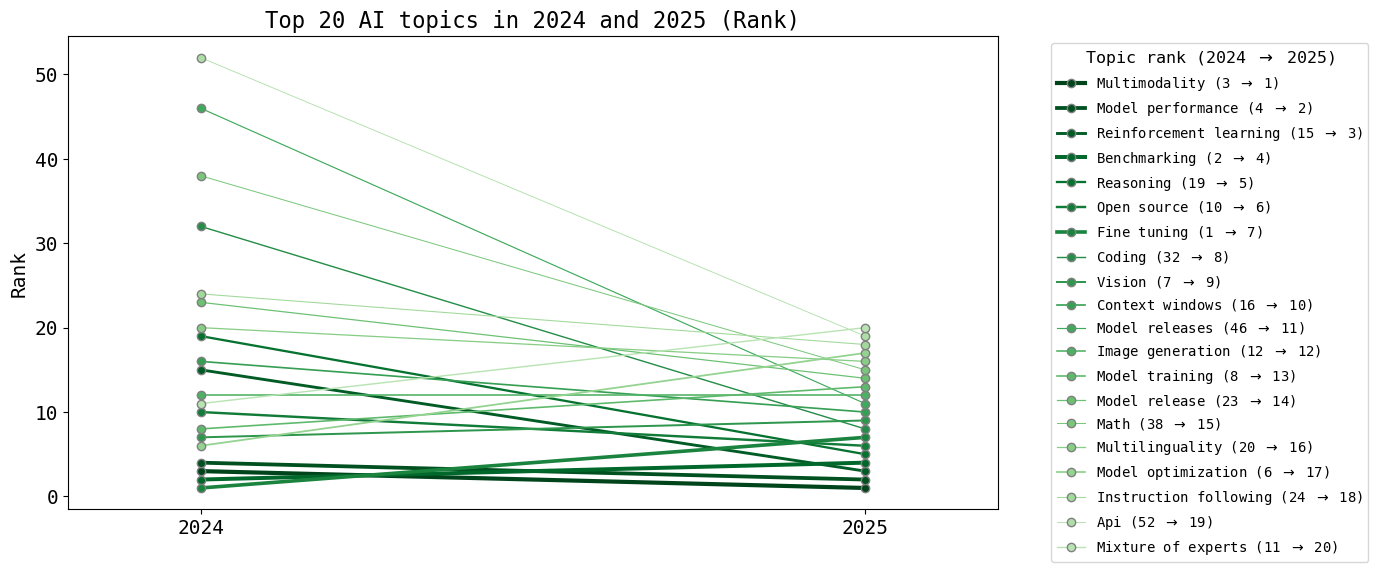

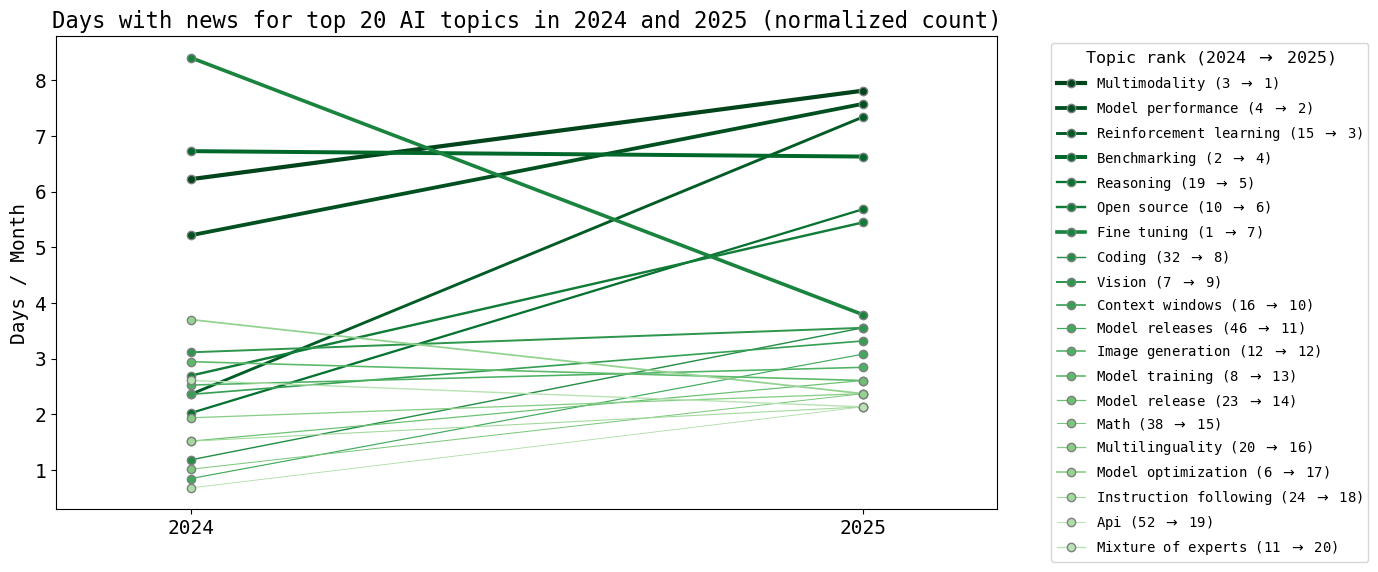

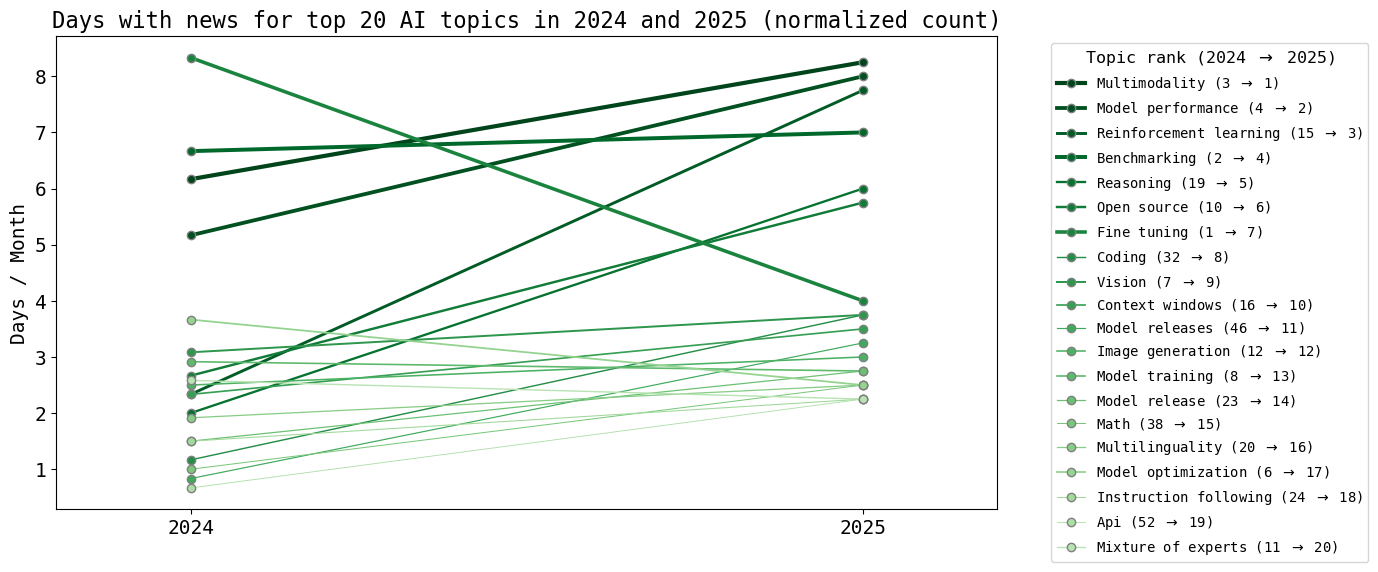

In [59]:
importlib.reload(ut)
# create datasets for plotting
df_tops_plot = ut.clean_data_slopegph(df_topics, mycol='topics', is_clean=False, is_norm_month=False, topk=20)
df_tops_plot_nrm = ut.clean_data_slopegph(df_topics, mycol='topics', is_clean=False, is_norm_month=True, topk=20)
# actual plot
ax1, dfr1 = ut.plot_slope_graph(df_nice=df_tops_plot, topk = 20, is_rank=True)
ax2, dfr2 = ut.plot_slope_graph(df_nice=df_tops_plot, topk = 20, is_rank=False)
ax3, dfr3 = ut.plot_slope_graph(df_nice=df_tops_plot_nrm, topk = 20, is_rank=False)

### New topics


1. Original topics are good, but I may be missing relevant tags
2. I'm going to transform the topics

In [20]:
# Let's review the original topics for cleansing
importlib.reload(ut)
res_ag = ut.explore_topic(df_topics, 'agent')
res_sty = ut.explore_topic(df_topics, 'safety')
res_int = ut.explore_topic(df_topics, 'interpretability')
res_rel = ut.explore_topic(df_topics, 'release')
res_reas = ut.explore_topic(df_topics, 'reason')
res_chea = ut.explore_topic(df_topics, 'cheat')
res_prompt = ut.explore_topic(df_topics, 'prompt')
res_mult = ut.explore_topic(df_topics, 'multimodal')
res_vid = ut.explore_topic(df_topics, 'video')
res_open = ut.explore_topic(df_topics, 'open')
res_bench = ut.explore_topic(df_topics, 'bench')
res_emot = ut.explore_topic(df_topics, 'emotion')
res_intel = ut.explore_topic(df_topics, 'intelligence')
res_agi = ut.explore_topic(df_topics, 'agi')
res_asi = ut.explore_topic(df_topics, 'asi')
res_intelligence = pd.concat([res_intel, res_agi, res_asi]).reset_index()
res_align = ut.explore_topic(df_topics, 'align')
res_model = ut.explore_topic(df_topics, 'model')
res_rag0 = ut.explore_topic(df_topics, 'rag')
res_rag1 = ut.explore_topic(df_topics, 'retrieval')
res_rag = pd.concat([res_rag0, res_rag1]).reset_index()
res_bio = ut.explore_topic(df_topics, 'biol')
res_rei = ut.explore_topic(df_topics, 'reinforcement')
res_quant = ut.explore_topic(df_topics, 'quantiz')
res_context = ut.explore_topic(df_topics, 'context')
res_context = res_context[res_context.topics.str.find('contextual') == -1]
res_opt = ut.explore_topic(df_topics, 'optimiz')
res_moe = ut.explore_topic(df_topics, 'mixture')
res_mod = ut.explore_topic(df_topics, 'model')
res_dis = ut.explore_topic(df_topics, 'distill')
res_data = ut.explore_topic(df_topics, 'dataset')
res_arch = ut.explore_topic(df_topics, 'archit')
res_code = ut.explore_topic(df_topics, 'code')
res_code = res_code[res_code.topics.str.find('encoder') == -1]
res_cot = ut.explore_topic(df_topics, 'chain')
res_fun = ut.explore_topic(df_topics, 'function')
res_har0 = ut.explore_topic(df_topics, 'hardware')
res_har1 = ut.explore_topic(df_topics, 'chip')
res_har2 = ut.explore_topic(df_topics, 'gpu')
res_har3 = ut.explore_topic(df_topics, '-tpu')
res_har = pd.concat([res_har0, res_har1, res_har2, res_har3]).reset_index()
res_chat = ut.explore_topic(df_topics, 'chat')

# print one for review
print(res_ag.head(5))

Topic: agent - 42 categories
Topic: safety - 6 categories
Topic: interpretability - 3 categories
Topic: release - 5 categories
Topic: reason - 25 categories
Topic: cheat - 0 categories
Topic: prompt - 23 categories
Topic: multimodal - 9 categories
Topic: video - 16 categories
Topic: open - 11 categories
Topic: bench - 15 categories
Topic: emotion - 3 categories
Topic: intelligence - 4 categories
Topic: agi - 6 categories
Topic: asi - 2 categories
Topic: align - 10 categories
Topic: model - 138 categories
Topic: rag - 5 categories
Topic: retrieval - 9 categories
Topic: biol - 1 categories
Topic: reinforcement - 2 categories
Topic: quantiz - 9 categories
Topic: context - 15 categories
Topic: optimiz - 40 categories
Topic: mixture - 4 categories
Topic: model - 138 categories
Topic: distill - 4 categories
Topic: dataset - 21 categories
Topic: archit - 12 categories
Topic: code - 22 categories
Topic: chain - 4 categories
Topic: function - 3 categories
Topic: hardware - 15 categories
Topic: 

In [22]:
importlib.reload(ut)
dict_ag = ut.convert_to_dict(res_ag, 'agents')
dict_sty = ut.convert_to_dict(res_sty, 'safety')
dict_int = ut.convert_to_dict(res_int, 'interpretability')
dict_rel = ut.convert_to_dict(res_rel[res_rel.topics.str.contains('model')], 'model_release')
dict_reas = ut.convert_to_dict(res_reas, 'reasoning')
dict_prompt = ut.convert_to_dict(res_prompt, 'prompting')
dict_multi = ut.convert_to_dict(res_mult, 'multimodal')
dict_vid = ut.convert_to_dict(res_vid, 'video')
dict_open = ut.convert_to_dict(res_open, 'open-source')
dict_bench = ut.convert_to_dict(res_bench, 'benchmark')
dict_intel = ut.convert_to_dict(res_intelligence, 'intelligence')
dict_align = ut.convert_to_dict(res_align, 'alignment')
dict_rag = ut.convert_to_dict(res_rag, 'RAG')
dict_rei = ut.convert_to_dict(res_rei, 'reinforcement')
dict_quant = ut.convert_to_dict(res_quant, 'quantization')
dict_opt = ut.convert_to_dict(res_opt, 'optimization')
dict_moe = ut.convert_to_dict(res_moe, 'MOE')
dict_dis = ut.convert_to_dict(res_dis, 'distillation')
dict_data = ut.convert_to_dict(res_data, 'dataset')
dict_arch = ut.convert_to_dict(res_arch, 'architecture')
dict_cont = ut.convert_to_dict(res_context, 'context-window')
dict_code = ut.convert_to_dict(res_code, 'code')
dict_cot = ut.convert_to_dict(res_cot, 'chain-of-thought')
dict_har = ut.convert_to_dict(res_har, 'hardware')
dict_chat = ut.convert_to_dict(res_chat, 'chatbot')
# get a list of all dictionaries
dict_all_lst = [dict_ag, dict_sty, dict_int, dict_rel, dict_reas, dict_prompt, dict_multi, 
            dict_vid, dict_open, dict_bench, dict_intel, dict_align, dict_rag, dict_rei, 
            dict_quant, dict_opt, dict_moe, dict_dis,
            dict_data, dict_arch, dict_cont, dict_code, dict_cot,
            dict_har, dict_chat]

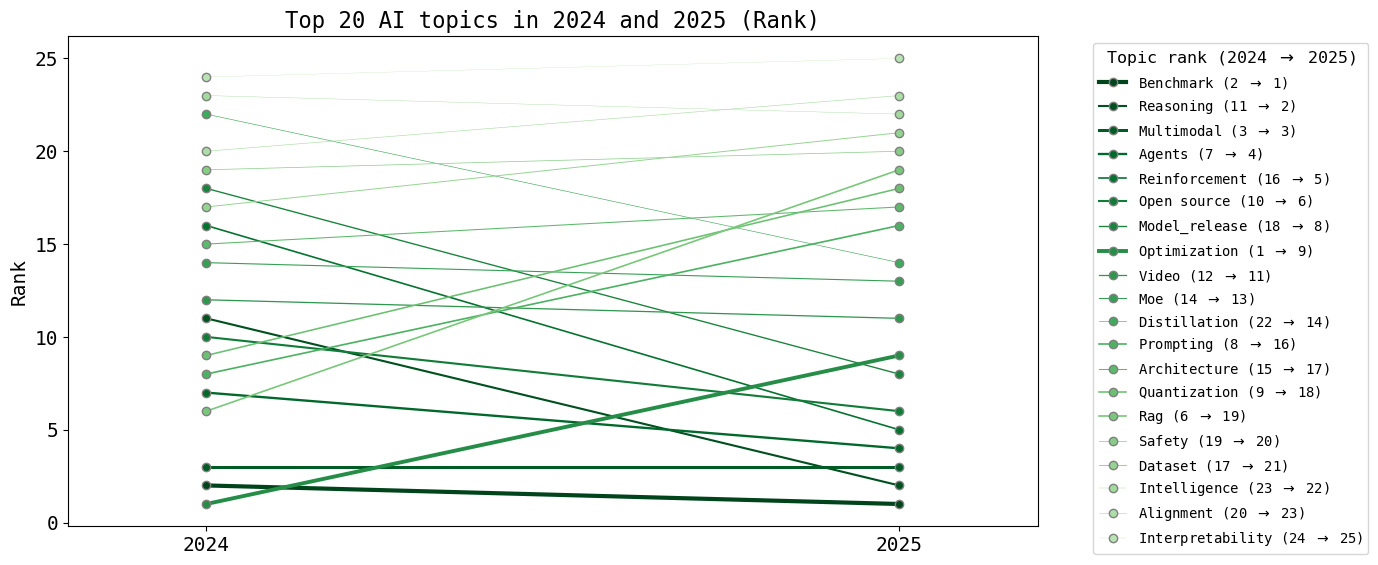

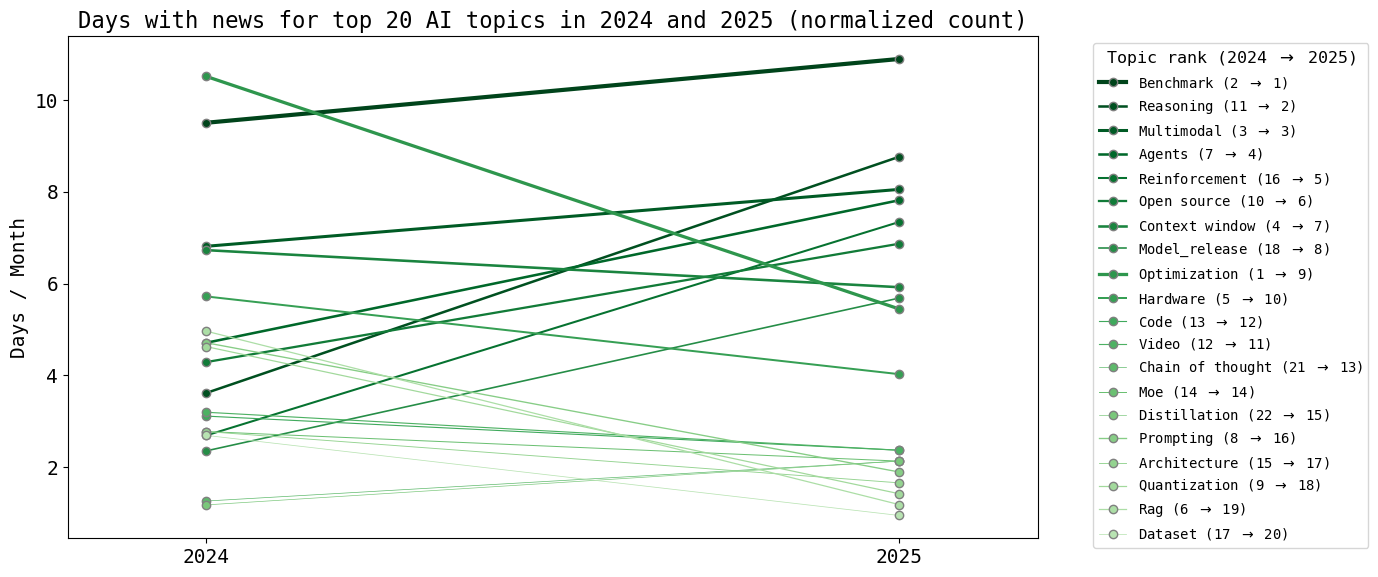

In [108]:
importlib.reload(ut)
# Create the clean data with the new topics
topk = 20
df_tops_plot_v1_nrm, df_tops_plot_v1 = ut.create_whole_data_per_topic_year(df_topics, mycol='topics', dict_all=dict_all_lst, topk = topk)
ax4, dfr4 = ut.plot_slope_graph(df_nice=df_tops_plot_v1, topk = topk, is_rank=True)
ax5, dfr5 = ut.plot_slope_graph(df_nice=df_tops_plot_v1_nrm, topk = topk, is_rank=False)




# Topics - time series

- With time series I can actually plot without normalization

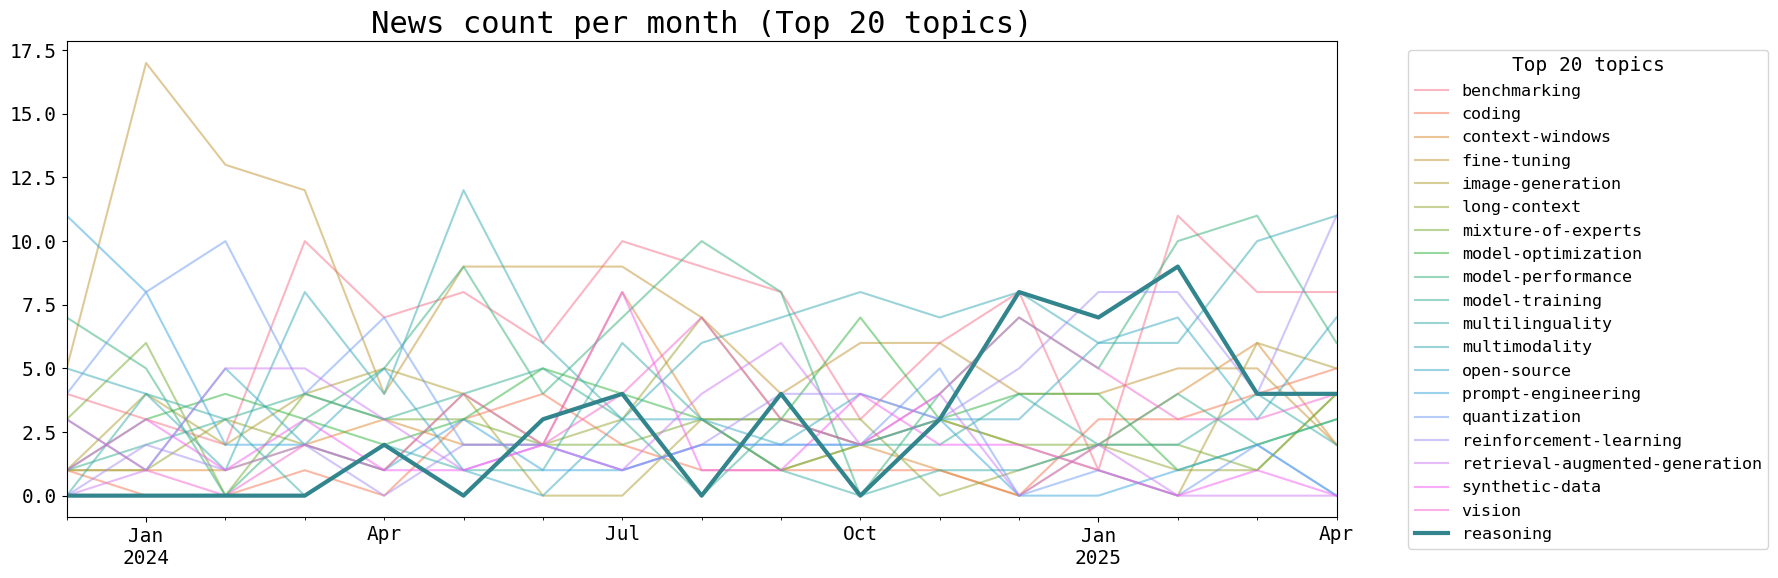

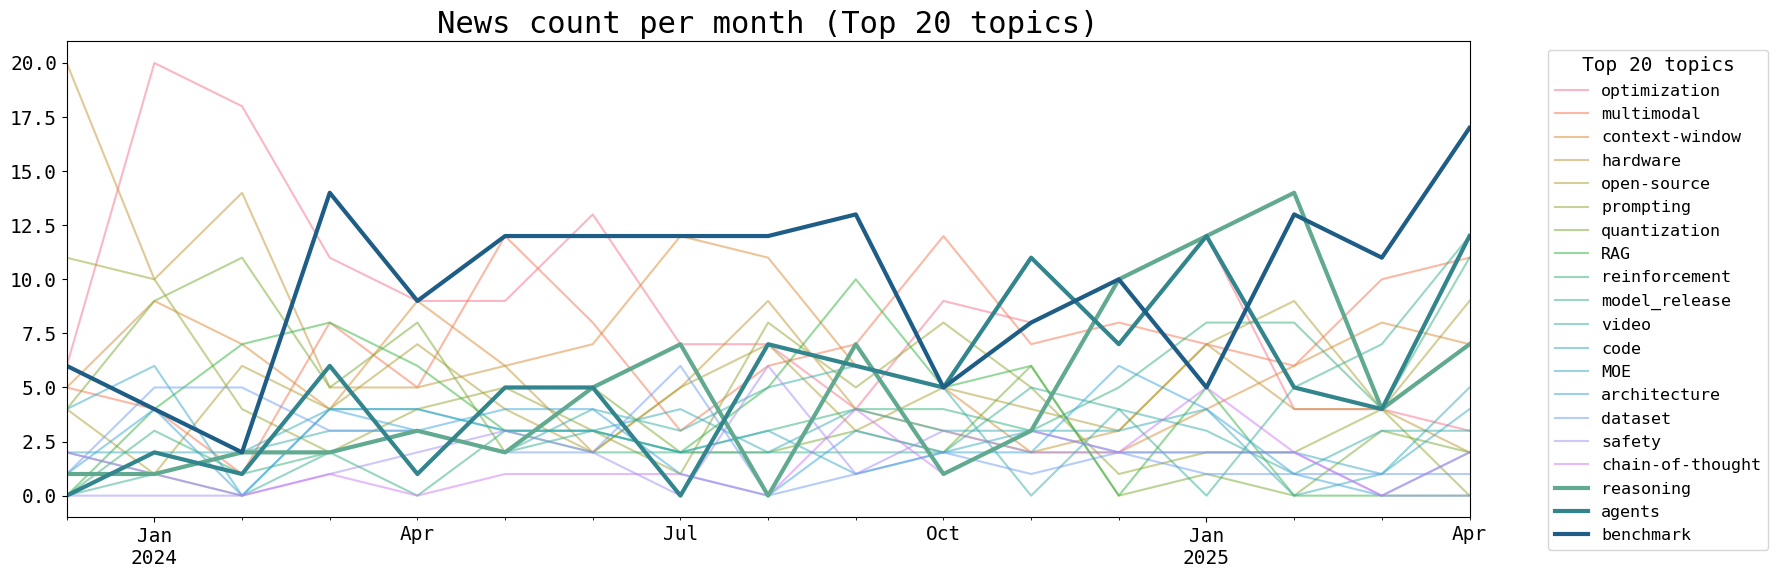

In [138]:
importlib.reload(ut)
topk = 20
df_ts_v0 = ut.create_time_series(df_topics, mycol='topics', topk=topk)
df_ts_v1 = ut.create_whole_data_per_topic_year_ts(df_topics, mycol='topics', topk=topk, date_granularity='month', dict_all=dict_all_lst)
ax0, df0 = ut.plot_top_k_topics(df_ts_v0, topk, single_out_topics = ['reasoning', 'agentic-ai'], mycol='topics', is_smooth=False, alpha_par = 0.3)
ax1, df1 = ut.plot_top_k_topics(df_ts_v1, topk, single_out_topics = ['reasoning', 'agents', 'benchmark'], mycol='topics', is_smooth=False, alpha_par = 0.3)


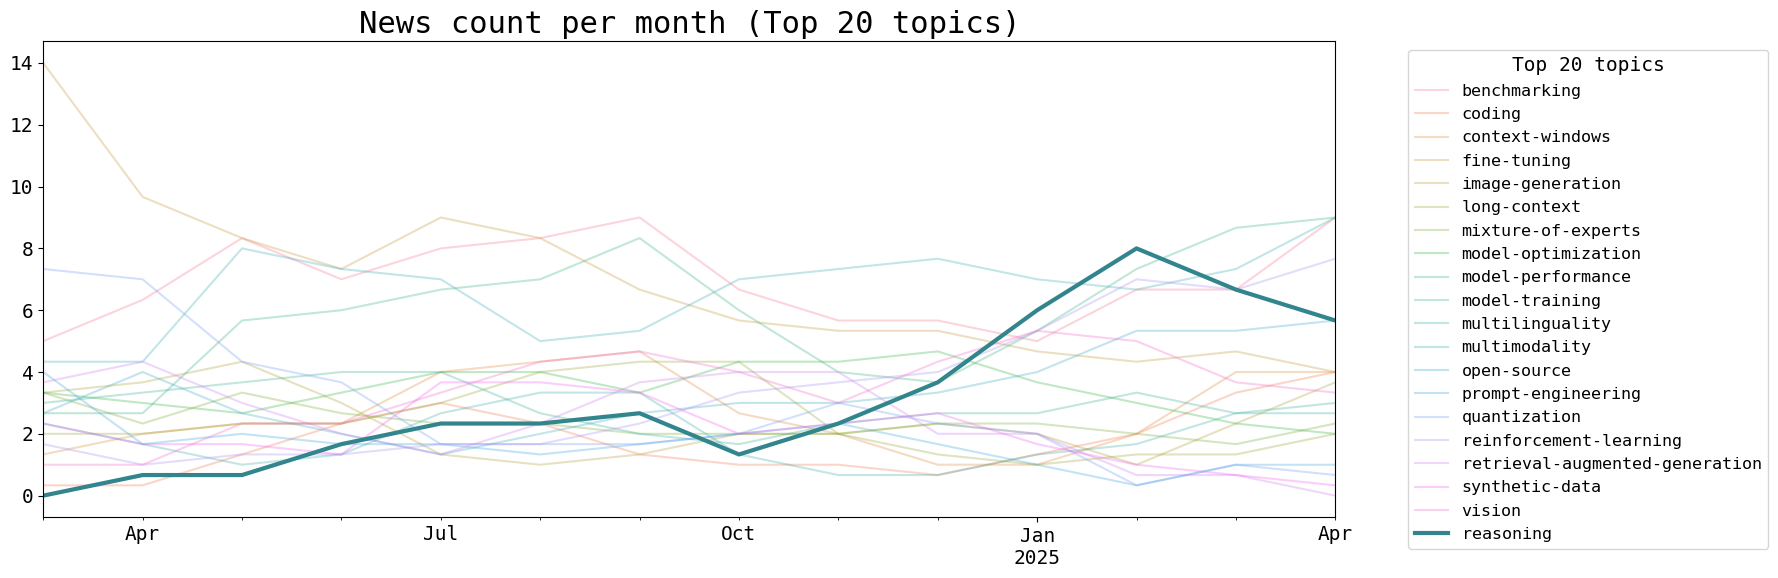

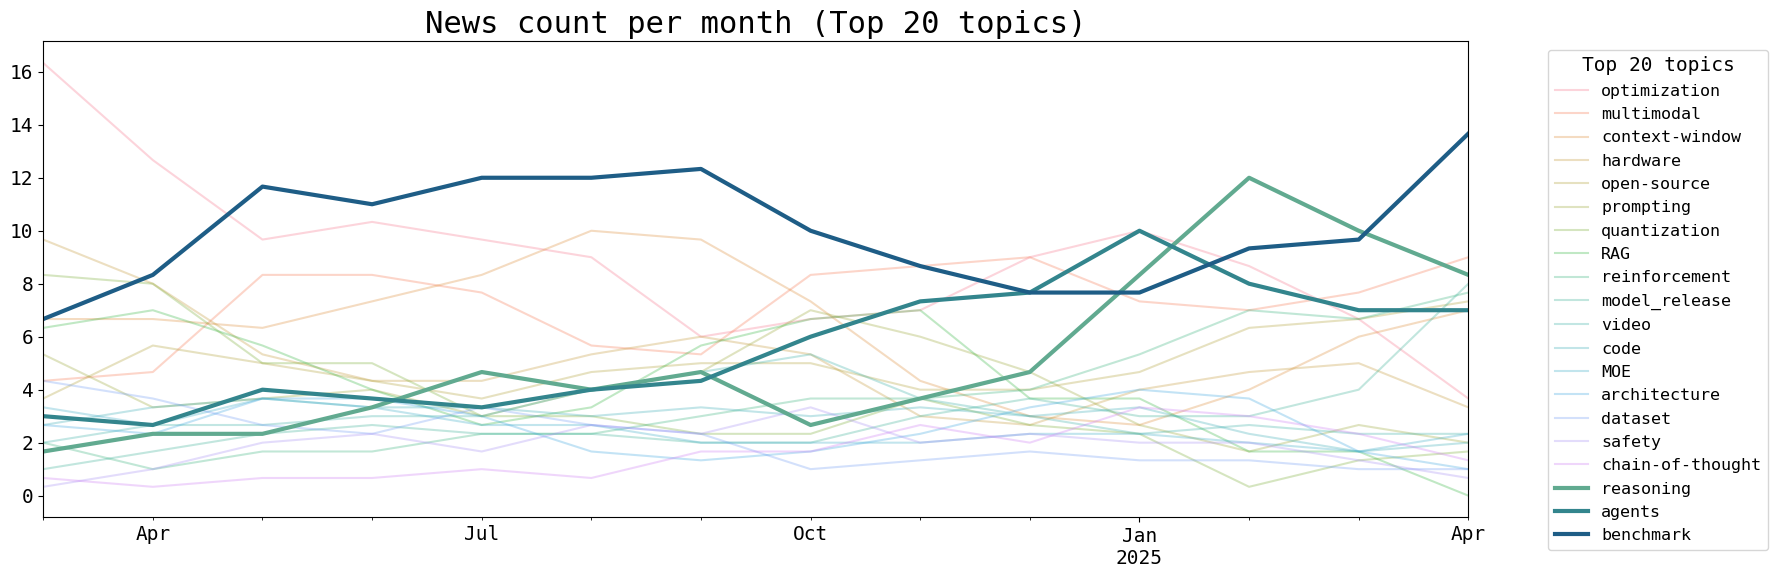

In [186]:
importlib.reload(ut)
topk = 20
df_ts_v0 = ut.create_time_series(df_topics, mycol='topics', topk=topk)
df_ts_v1 = ut.create_whole_data_per_topic_year_ts(df_topics, mycol='topics', topk=topk, date_granularity='month', dict_all=dict_all_lst)
ax0, df0 = ut.plot_top_k_topics(df_ts_v0, topk, single_out_topics = ['reasoning', 'agentic-ai'], mycol='topics', is_smooth=True, alpha_par = 0.3)
ax1, df1 = ut.plot_top_k_topics(df_ts_v1, topk, single_out_topics = ['reasoning', 'agents', 'benchmark'], mycol='topics', is_smooth=True, alpha_par = 0.3)


# Companies & Models

- I first had to do some cleaning
    - Original data has the actual model-version
    - But I wanted to map this to model or company

In [160]:
# I passed the list of top 200 models-version to chatgpt and asked to extract the name only
importlib.reload(ut)
dict_model_chatgpt = pd.read_csv('Model_Version_to_Base_Model_Mapping.csv')
dict_model_chatgpt = dict_model_chatgpt.set_index('model_version')['base_model'].to_dict()

# Now map to company: I have to do a fix for the o1 model
dict_model_company = pd.read_csv('Model_Version_to_Company_Mapping.csv')
dict_model_company = dict_model_company.set_index('model_version')['company'].to_dict()
# dict_model_company1 = dict_model_company.copy()
# dict_model_company1 = {k: ut.fix_model_name(k,dict_model_company, is_company = True) for k, v in dict_model_company1.items()}



In [175]:
df_models['my_models'] = df_models.models.replace(dict_model_chatgpt)
df_models['my_company'] = df_models.models.replace(dict_model_company)

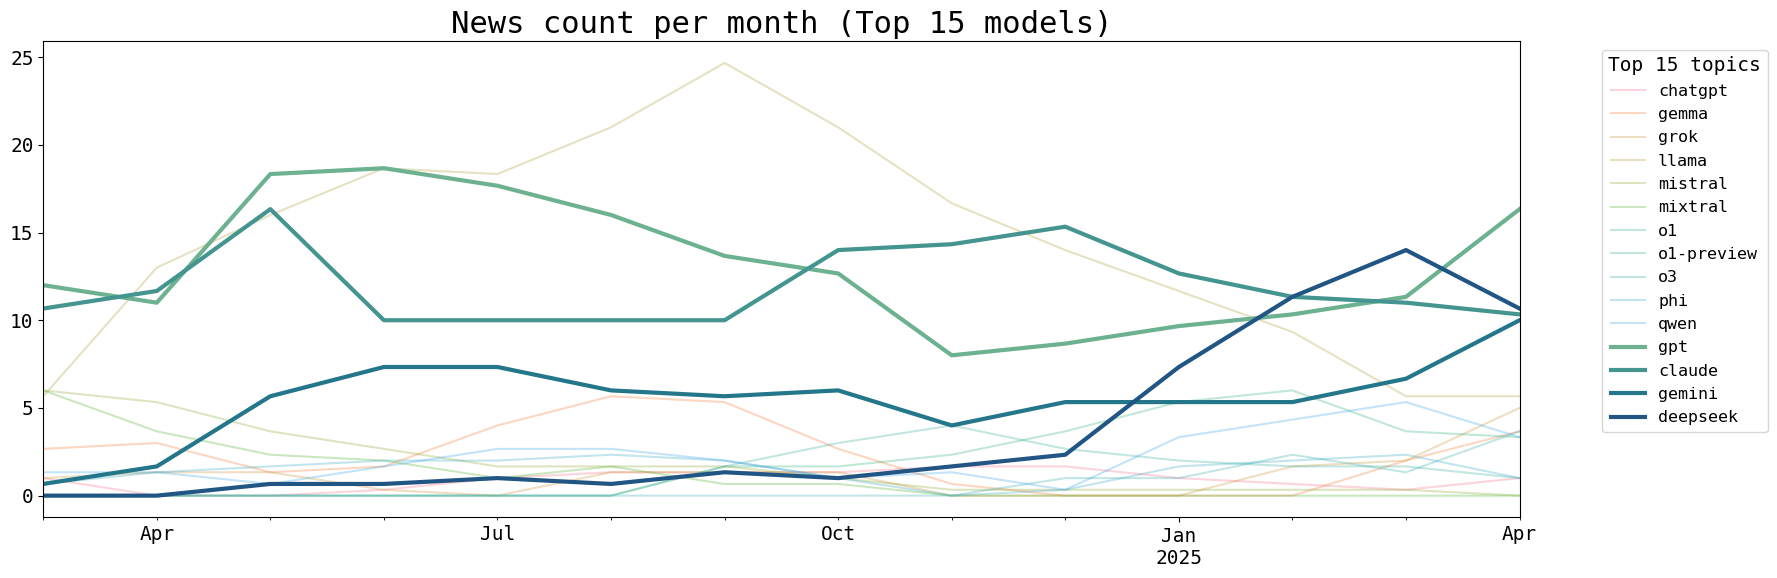

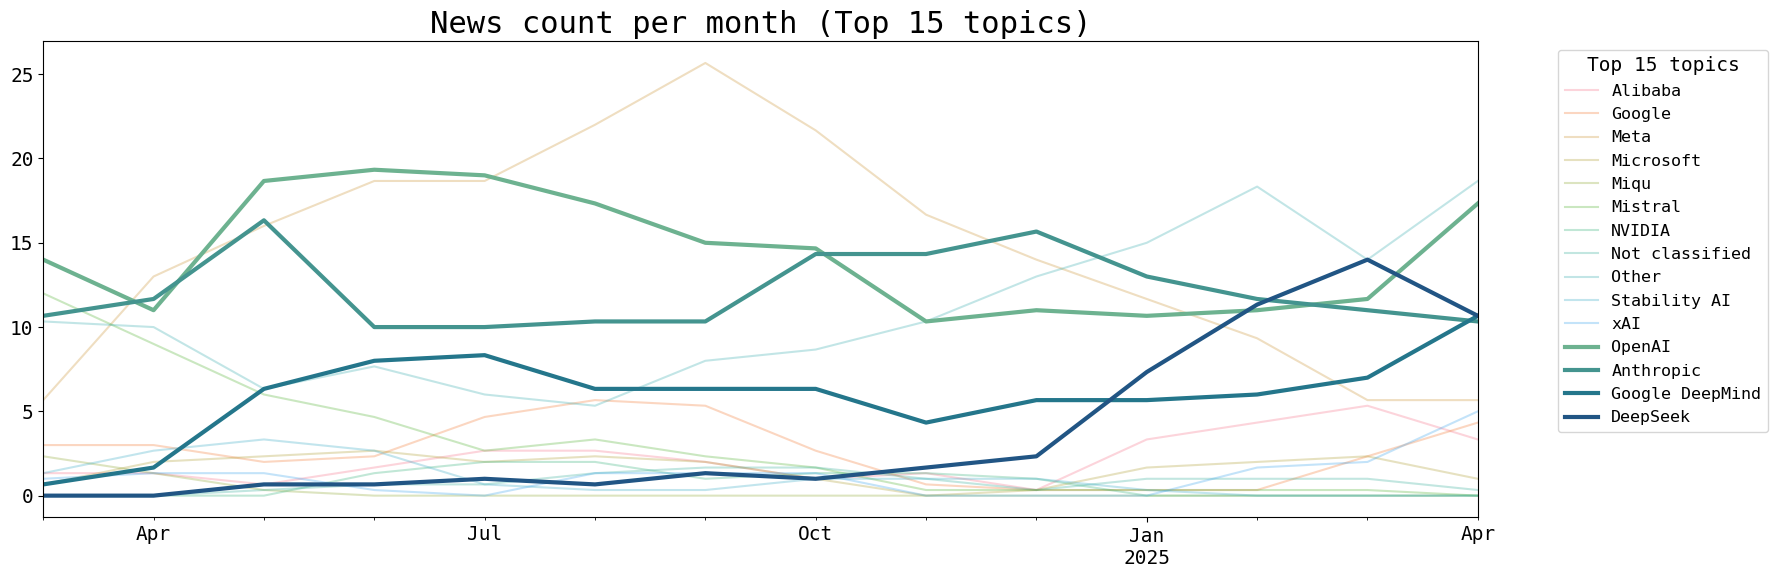

In [199]:
topk = 15
df_ts_mod = ut.create_time_series(df_aug=df_models, mycol = 'my_models', topk=topk)
df_ts_com = ut.create_time_series(df_aug=df_models, mycol = 'my_company', topk=topk)
ax0, df0 = ut.plot_top_k_topics(df_ts_mod, topk, single_out_topics = ['gpt', 'claude', 'gemini', 'deepseek'], mycol='topics', is_smooth=True, alpha_par = 0.3)
ttl = ax0.set_title(f'News count per month (Top {topk} models)'.format(topk=topk))

ax1, df1 = ut.plot_top_k_topics(df_ts_com, topk, single_out_topics = ['OpenAI', 'Anthropic', 'Google DeepMind', 'DeepSeek'], mycol='topics', is_smooth=True, alpha_par = 0.3)
# ttl = ax0.set_title(f'News count per month (Top {topk} models)'.format(topk=topk))

